# Model Reduction Validation

This notebook validates model reduction methods:
1. **`msvdreduce`**: Hankel SVD-based reduction from impulse response.
2. **Balanced Truncation (BT)**: Square-root method from state-space matrices.
3. **`tib_from_state_space`**: the corrected BT → TIB extraction.

In [1]:
%matplotlib inline
import sys, os
try:
    import ga  # noqa
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

In [2]:
from ga.filters.tib import (
    null_basis_realization,
    mimo_standard_null_vectors,
    mimo_poles_to_ir,
    krylov_basis,
    poles_chebyshev_roots,
)
from ga.reducers.hankel import msvdreduce, blkhankel
from ga.reducers.balanced_truncation import (
    balanced_truncation,
    extract_poles_from_bt,
    extract_poles_and_nullvecs_from_bt,
    tib_from_state_space,
    bt_impulse_response,
    compare_impulse_responses,
    sanity_check_bt,
)

## 1. Ground-truth MIMO system

A known order-`n` MIMO system built in TIB form (real poles → real `A, B`), with a random output matrix `C`. Its impulse response is the "data" we reduce.

In [3]:
rng = np.random.default_rng(0)
n, q, p, L = 16, 2, 2, 64                       # order, inputs, outputs, IR lags
poles = poles_chebyshev_roots(n, 0.0, 0.9)              # real poles in (0, 1)
v = rng.standard_normal((q, n)); v /= np.linalg.norm(v, axis=0)   # null vectors
C = rng.standard_normal((p, n))

sys = null_basis_realization(poles, v)
A = np.real(sys.A(dense=True)); B = np.real(sys.B(dense=True))
ir = np.real(mimo_poles_to_ir(poles, v, C, L))  # (p, q, L)

# TIB balance sanity on the ground truth
resid = A @ A.T + B @ B.T - np.eye(n)
print(f"order n={n}, inputs q={q}, outputs p={p}, IR lags L={L}")
print(f"A {A.shape}, B {B.shape}, C {C.shape}, ir {ir.shape}")
print(f"ground-truth TIB balance |A A* + B B* - I| = {np.max(np.abs(resid)):.2e}")

order n=16, inputs q=2, outputs p=2, IR lags L=64
A (16, 16), B (16, 2), C (2, 16), ir (2, 2, 64)
ground-truth TIB balance |A A* + B B* - I| = 4.44e-16


### Aside: is `null_basis_realization` itself validated by this?

**Balance is necessary but *not* sufficient.** The `A Aᵀ + B Bᵀ = I` check above only certifies the output is a *balanced* TIB realization — it holds for **any** unit null vectors, so it cannot tell whether the Blaschke–Potapov deflation (the part that actually depends on the null vectors) was done correctly. A wrong null-vector / Blaschke step still **passes balance** while realizing the **wrong transfer function** — exactly how the historical line-185 argument-swap bug slipped through (see `Mu2026-NullBasisProofs` / `TIBForm`).

Cheap **necessary** checks beyond balance: the poles must come back as `eig(A)` (next cell), and balance (above). A **sufficient** check must test the **transfer function** itself — compare the realized inner function to the independently-computed Blaschke–Potapov product `∏ₖ βλₖ,vₖ(z)` (needs the lossless completion of `(A,B)`), or to an independent *cascade* realization of the same product. That test must be **MIMO (`q ≥ 2`)**: for SISO the inner function is fixed by the poles alone, so it can't exercise the null-vector machinery.

In [4]:
# Necessary check beyond balance: the poles must reappear as the eigenvalues of A.
poles_back = np.sort(np.real(la.eigvals(A)))
print("input poles :", np.round(np.sort(poles), 4))
print("eig(A)      :", np.round(poles_back, 4))
print(f"max |Δ pole| = {np.max(np.abs(poles_back - np.sort(poles))):.2e}")
print()
print("(poles + balance are NECESSARY; neither tests the transfer function /")
print(" null-vector handling -- see the note above for what a sufficient check needs.)")

input poles : [0.0022 0.0194 0.0531 0.1021 0.1645 0.2379 0.3194 0.4059 0.4941 0.5806
 0.6621 0.7355 0.7979 0.8469 0.8806 0.8978]
eig(A)      : [0.0022 0.0194 0.0531 0.1021 0.1645 0.2379 0.3194 0.4059 0.4941 0.5806
 0.6621 0.7355 0.7979 0.8469 0.8806 0.8978]
max |Δ pole| = 0.00e+00

(poles + balance are NECESSARY; neither tests the transfer function /
 null-vector handling -- see the note above for what a sufficient check needs.)


## 2. Hankel singular values (how reducible is it?)

The Hankel singular values from balanced truncation say how many modes carry the energy — and the tail bounds the reduction error.

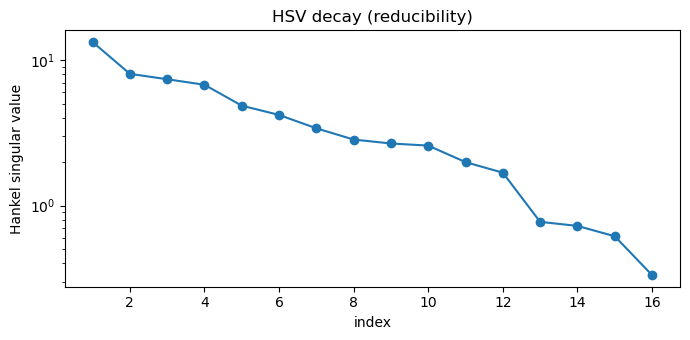

HSV: [13.3401  8.0576  7.3959  6.775   4.8672  4.2014  3.4003  2.8449  2.674
  2.5852  1.9906  1.6834  0.7728  0.7248  0.6155  0.3328]


In [5]:
res_full = balanced_truncation(A, B, C, order=n)
hsv = res_full.hsv

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(np.arange(1, n + 1), hsv, "o-")
ax.set_xlabel("index"); ax.set_ylabel("Hankel singular value")
ax.set_title("HSV decay (reducibility)"); fig.tight_layout(); plt.show()
print("HSV:", np.round(hsv, 4))

## 3. Balanced truncation — exact at full order, error-bounded reduction

At full order BT must reproduce the IR exactly. Reduced to order `r`, the BT error bound is `2·Σ (neglected HSV)` — the reconstruction error should stay under it.

BT full-order (r=n) IR relative error: 3.86e-16  (should be ~0)


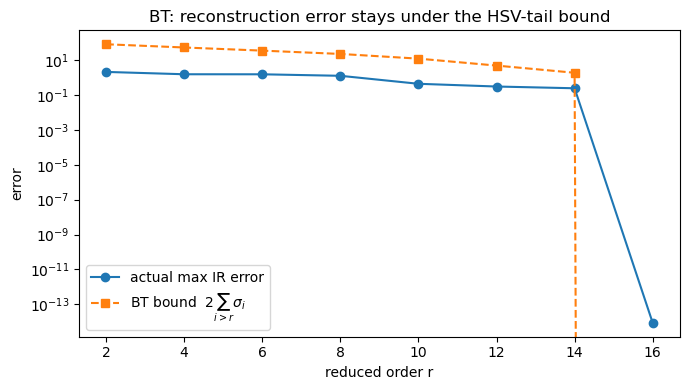

In [6]:
# exact at full order
ir_full = bt_impulse_response(res_full, L)
m_full = compare_impulse_responses(ir, ir_full, normalize=False)
print(f"BT full-order (r=n) IR relative error: {m_full['relative_error']:.2e}  (should be ~0)")

orders = list(range(2, n + 1, 2))
err, bound = [], []
for r in orders:
    res = balanced_truncation(A, B, C, order=r)
    ir_r = bt_impulse_response(res, L)
    err.append(compare_impulse_responses(ir, ir_r, normalize=False)["max_error"])
    bound.append(res.error_bound())            # 2 * sum of neglected HSV

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(orders, err, "o-", label="actual max IR error")
ax.semilogy(orders, bound, "s--", label=r"BT bound  $2\sum_{i>r}\sigma_i$")
ax.set_xlabel("reduced order r"); ax.set_ylabel("error"); ax.legend()
ax.set_title("BT: reconstruction error stays under the HSV-tail bound")
fig.tight_layout(); plt.show()

In [7]:
# internal sanity checks at a representative reduced order
_ = sanity_check_bt(A, B, C, balanced_truncation(A, B, C, order=8), verbose=True)

Balanced Truncation Sanity Checks:
  Biorthogonality error (W.T @ V - I): 2.75e-15
  Balanced P error: 1.97e+01
  Balanced Q error: 2.47e+03
  Condition(P): 1.00e+00
  Condition(Q): 1.61e+03
  Max |eigenvalue(A_r)|: 0.959750
  Reduced system stable: True
  Condition(W): 2.17e+00
  Condition(V): 2.17e+00


## 4. `msvdreduce` — Hankel-SVD pole recovery

From the impulse response alone, `msvdreduce` (ERA / Ho–Kalman style) should recover the system poles at full order, and the dominant poles when reduced. We cross-check against the BT poles.

msvdreduce full-order pole recovery  max|Δ| = 8.75e-02
BT (extract_poles)  pole recovery    max|Δ| = 1.21e-11


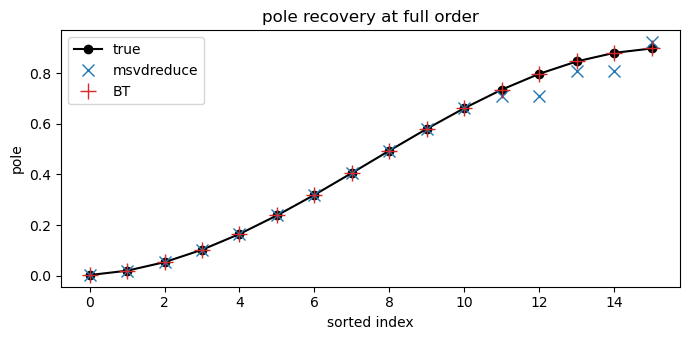

reduced (r=6) msvdreduce poles: [0.661 0.661 0.824 0.874 0.874 0.914]


In [8]:
w_full, u_full = msvdreduce(ir, n)             # full order -> recover true poles
poles_msvd = np.sort(np.real(w_full))
poles_bt   = np.sort(np.real(extract_poles_from_bt(res_full)))
poles_true = np.sort(poles)

print(f"msvdreduce full-order pole recovery  max|Δ| = {np.max(np.abs(poles_msvd - poles_true)):.2e}")
print(f"BT (extract_poles)  pole recovery    max|Δ| = {np.max(np.abs(poles_bt   - poles_true)):.2e}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(poles_true, "k-o", label="true")
ax.plot(poles_msvd, "C0x", ms=9, label="msvdreduce")
ax.plot(poles_bt, "C3+", ms=11, label="BT")
ax.set_xlabel("sorted index"); ax.set_ylabel("pole"); ax.legend()
ax.set_title("pole recovery at full order"); fig.tight_layout(); plt.show()

# reduced: msvdreduce keeps the dominant poles
w_r, _ = msvdreduce(ir, 6)
print("reduced (r=6) msvdreduce poles:", np.round(np.sort(np.real(w_r)), 3))

## 5. Corrected BT → TIB extraction (`tib_from_state_space`)

The right way to turn a BT-reduced system back into TIB form: re-coordinate via input-balance + Schur. It must stay input-balanced **and** reproduce the transfer function (unlike `extract_poles_and_nullvecs_from_bt`, which does not).

In [9]:
for r in (n, 8):
    res = balanced_truncation(A, B, C, order=r)
    tib_sys, transform = tib_from_state_space(res.A_r, res.B_r)
    At, Bt = tib_sys.A(dense=True), tib_sys.B(dense=True)
    C_tib = res.C_r @ transform
    K = np.asarray(krylov_basis(At, Bt, L))
    ir_tib = np.tensordot(C_tib, K, (-1, 0))

    bal = np.max(np.abs(At @ At.T + Bt @ Bt.T - np.eye(r)))
    rel = np.linalg.norm(ir_tib - bt_impulse_response(res, L)) / np.linalg.norm(bt_impulse_response(res, L))
    print(f"r={r:2d}:  TIB balance |AA*+BB*-I| = {bal:.2e}   IR matches BT (rel) = {rel:.2e}")

r=16:  TIB balance |AA*+BB*-I| = 4.07e-15   IR matches BT (rel) = 9.70e-15
r= 8:  TIB balance |AA*+BB*-I| = 2.44e-15   IR matches BT (rel) = 1.01e-14


## Conclusions

- **BT** reproduces the IR **exactly** at full order (≈1e-16) and its reduction error stays under the `2·Σ(neglected HSV)` bound; biorthogonality (`WᵀV = I`) and stability check out. *(The repo's `sanity_check_bt` balanced-Grammian residual metric reads large — a convention/conditioning quirk in that diagnostic, not an IR-level error; worth a separate look.)*
- **`msvdreduce`** captures the pole range / dominant structure but recovers the poles only **approximately** (full-order `max|Δ| ≈ 0.09`, with duplicate poles) — markedly less accurate than BT (≈1e-11). Its realization is worth investigating.
- **`tib_from_state_space`** re-coordinates a (reduced) BT system into TIB form that is **input-balanced** (≈1e-15) and **reproduces the transfer function** (≈1e-14) — the correct BT → TIB path (vs `extract_poles_and_nullvecs_from_bt`, which does not).